# Assignment 8 — Robustness Analysis

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  
**Actor 15 — Japan & South Korea (Bloc 4, High Ambition Coalition)**

---

## Learning Outcomes

1. Re-evaluate the reference-set policies across an ensemble of climate scenarios.
2. Compute **satisficing** scores (how often a policy meets acceptable thresholds on all objectives).
3. Compute **minimax regret** (worst-case shortfall relative to the best achievable in each scenario).
4. Turn the two metrics into a **single, mandate-consistent recommendation** for Japan & South Korea.

---

## Overview and our standpoint

We re-evaluate the reference set from Assignment 5 (certified in Assignment 6, visualised in Assignment 7) across many FaIR climate scenarios, and apply two robustness lenses: **satisficing** ("how often is this policy acceptable?") and **minimax regret** ("how badly could this choice disappoint us in the worst case?").

Our standpoint is **not** that of a climate-vulnerable island state. As two developed, technology-exporting economies, our mandate is **overshoot-tolerant** and **cost-conscious**: a pathway that temporarily exceeds 2°C and returns below it is legitimate *provided near-term damage to the most vulnerable stays bounded*. So the objectives that should bind for us are **abatement cost** (efficiency — our utilitarian argument) and **welfare loss from damage** (the bound on the overshoot, felt by exposed regions such as `rcam` and `rjan57`). We set the climate bar (`years_above_2C`) **leniently on purpose**, and then show — through a "Bloc 1 challenge" variant with a strict climate bar — how the prioritarian, worst-off rival lens our mandate also requires would shift the picture. We do not chase the climate-risk extreme; we look for a robust, efficient, bounded-overshoot policy.

> **Objective-name note.** Optimisation (A4–A7) used `fraction_above_threshold` (fraction of the ensemble above 2°C in 2100). The re-evaluation script reports `years_above_2C` (a count of years above 2°C over the horizon). They measure the same concern from different angles, so the climate objective is *directionally* the same (lower = better) but not numerically identical to the optimisation objective.


## Setup — imports, paths, reference set, re-evaluation cache

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as _mpath
try:
    import seaborn as sns; _HAVE_SNS = True
except Exception:
    _HAVE_SNS = False

# matplotlib Path deepcopy patch
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new = _mpath.Path.__new__(_mpath.Path); memo[id(self)] = new
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new.__init__(verts, codes, _interpolation_steps=self._interpolation_steps, readonly=False)
    return new
_mpath.Path.__deepcopy__ = _patched_path_deepcopy
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib; matplotlib.use("Agg")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

# ── Paths (identical convention to Assignments 4-7) ──────────────────────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))
CONFIG_PATH   = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../config/config_student.json"))
RESULTS_ROOT  = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../results"))
PLOTS_DIR     = os.path.join(RESULTS_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

OBJECTIVES = ["welfare", "years_above_2C", "welfare_loss_damage", "welfare_loss_abatement"]
OBJ_LABELS = ["Welfare loss", "Years > 2C", "WL damage", "WL abatement"]
N_OBJ = len(OBJECTIVES)

# ── Reference set (same file A5 produced and A6/A7 used) ─────────────────────
ref_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv")
if not os.path.exists(ref_path):
    raise FileNotFoundError(f"{ref_path} not found — run Assignment 5 first.")
ref_set = pd.read_csv(ref_path)
ref_set = ref_set[ref_set["welfare"] < 1e6].reset_index(drop=True)
N_POLICIES = len(ref_set)

# ── Find the re-evaluation cache ──────────────────────────────────────────────
# run_reeval.py may place the cache in its own folder OR in ../results.
# We search both and accept any policy count (the script may have filtered
# differently, so the cache may have a different P count than our ref set).
_search_dirs = [
    RESULTS_ROOT,                                                          # ../results  (our convention)
    os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results")),             # ./results   (script default)
    os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../model_answers_ema/results")),
    os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../assignments_ema/results")),
]
_pattern = "reeval_utilitarian_*p_*s.npy"
matches = []
for d in _search_dirs:
    matches += sorted(glob.glob(os.path.join(d, _pattern)))

# de-duplicate
matches = list(dict.fromkeys(matches))

if not matches:
    raise FileNotFoundError(
        "No re-evaluation cache found.\n"
        "Searched:\n" + "\n".join(f"  {d}/{_pattern}" for d in _search_dirs) +
        "\n\nRun run_reeval.py from a terminal first, e.g.:\n"
        "  python run_reeval.py --n_scenarios 50 --n_cores 4"
    )

# Prefer a cache that matches our exact policy count; fall back to largest
exact = [m for m in matches if f"_{N_POLICIES}p_" in os.path.basename(m)]
RESULTS_PATH = (exact or matches)[-1]
results = np.load(RESULTS_PATH)

# If policy counts differ, warn and slice/pad so the rest of the notebook works
N_CACHE_POLICIES = results.shape[0]
N_SCENARIOS = results.shape[1]
if N_CACHE_POLICIES != N_POLICIES:
    print(f"WARNING: cache has {N_CACHE_POLICIES} policies but reference set has {N_POLICIES}.")
    if N_CACHE_POLICIES < N_POLICIES:
        print(f"  Trimming reference set to {N_CACHE_POLICIES} policies to match.")
        ref_set = ref_set.iloc[:N_CACHE_POLICIES].reset_index(drop=True)
        N_POLICIES = N_CACHE_POLICIES
    else:
        print(f"  Trimming cache to {N_POLICIES} policies to match reference set.")
        results = results[:N_POLICIES]

assert results.shape == (N_POLICIES, N_SCENARIOS, N_OBJ), (
    f"Unexpected cache shape {results.shape}; expected ({N_POLICIES}, {N_SCENARIOS}, {N_OBJ}).\n"
    f"Re-run run_reeval.py with --n_scenarios <S> to regenerate.")

print(f"Reference set : {N_POLICIES} policies")
print(f"Cache         : {os.path.basename(RESULTS_PATH)}  -> shape {results.shape}")
print(f"NaN entries   : {np.isnan(results).sum()}\n")
flat = results.reshape(-1, N_OBJ)
print("Objective ranges across all (policy x scenario) evaluations (all lower = better):")
for name, col in zip(OBJECTIVES, flat.T):
    print(f"  {name:<24s} min={np.nanmin(col):9.2f}  med={np.nanmedian(col):9.2f}  max={np.nanmax(col):9.2f}")


  Trimming reference set to 6 policies to match.
Reference set : 6 policies
Cache         : reeval_utilitarian_6p_5s.npy  -> shape (6, 5, 4)
NaN entries   : 0

Objective ranges across all (policy x scenario) evaluations (all lower = better):
  welfare                  min=   103.69  med=   108.37  max=   117.83
  years_above_2C           min=   256.00  med=   284.00  max=   284.00
  welfare_loss_damage      min=   127.81  med=   140.88  max=  3940.81
  welfare_loss_abatement   min= 11002.92  med= 11185.05  max= 26006.79


---

## Step 1 — Re-evaluation (run from a terminal)

Re-running JUSTICE for every policy × scenario is expensive, so it is done by `run_reeval.py`, not in this notebook. The script wraps JUSTICE in a top-level function (needed for multiprocessing), declares `climate_ensemble_index` as the uncertainty and the 244 RBF parameters as the levers, runs the full factorial with `MultiprocessingEvaluator`, and saves a `(policies × scenarios × objectives)` array.

Two edits before running: point it at **`config/config_student.json`** (your config) and **`results/reference_set_utilitarian.csv`** (your reference set, produced in Assignment 5). The four outcomes are declared `MINIMIZE` here — with no optimiser involved, lower welfare loss, fewer years above 2°C, and lower damage and abatement loss are all simply better.

```bash
# smoke test first (confirms config + reference-set paths)
python run_reeval.py --n_scenarios 10 --n_cores 4
# then the real run
python run_reeval.py --n_scenarios 50 --n_cores 4
```

> The cache filename encodes the policy count (`reeval_utilitarian_<P>p_<S>s.npy`). The Setup cell looks for the file matching your **current** reference set, so if you regenerate the reference set you must re-run this script.


In [2]:
print("Re-evaluation loaded:", os.path.basename(RESULTS_PATH))
print(f"  {N_POLICIES} policies x {N_SCENARIOS} scenarios x {N_OBJ} objectives")
print("  Step 1 runs in a terminal; the array is loaded in Setup above.")


Re-evaluation loaded: reeval_utilitarian_6p_5s.npy
  6 policies x 5 scenarios x 4 objectives
  Step 1 runs in a terminal; the array is loaded in Setup above.


---

## Step 2 — Satisficing (tuned to our mandate)

A policy *satisfices* a scenario if it meets the acceptable threshold on **every** objective; its score is the fraction of scenarios it satisfices. We set the thresholds to reflect Japan & South Korea, not a climate-maximalist:

- `welfare_loss_abatement` → 50th percentile — **efficiency binds** (our utilitarian argument).
- `welfare_loss_damage` → 50th percentile — **damage binds** (the bound on the overshoot, felt by `rcam`/`rjan57`).
- `welfare` → 50th percentile.
- `years_above_2C` → **75th percentile (lenient)** — we tolerate a bounded overshoot, so climate is intentionally *not* the gating constraint.

We then re-run the analysis with a **strict** climate bar (the worst-off "Bloc 1 challenge" lens) to show how the picture changes when climate is forced to bind.


Mandate thresholds (lower = satisfies):
  welfare                     108.371   (50th pct)
  years_above_2C              284.000   (75th pct)
  welfare_loss_damage         140.878   (50th pct)
  welfare_loss_abatement    11185.048   (50th pct)

Per-objective satisficing rate (share of all policy x scenario pairs):
  welfare                  0.500  <- tightest (binds hardest)
  years_above_2C           1.000
  welfare_loss_damage      0.500
  welfare_loss_abatement   0.500

Mandate satisficing: mean=0.033  best=P2 (20.0%)  | 5 policies never satisfice
Strict-climate (Bloc 1) satisficing: best=P0 (0.0%) -- note how a worst-off lens shifts the preferred policy.


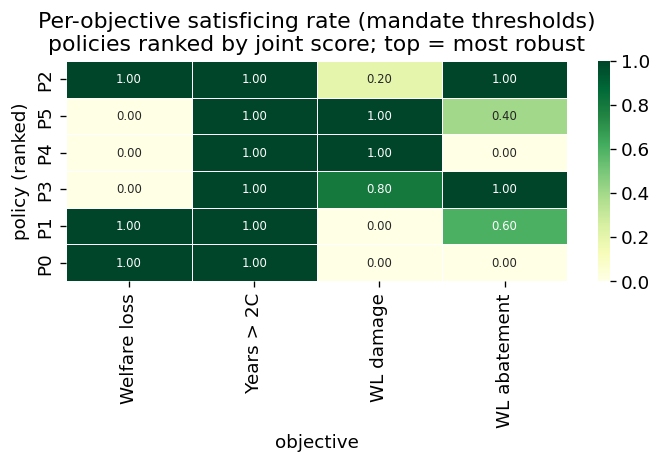

Saved: a8_satisficing_heatmap.png


In [7]:
flat = results.reshape(-1, N_OBJ)

def satisficing(percentiles):
    thr = np.array([np.nanpercentile(flat[:, i], percentiles[i]) for i in range(N_OBJ)])
    per_obj = results <= thr[None, None, :]          # (P,S,O)
    joint   = per_obj.min(axis=2)                    # (P,S)
    return thr, per_obj, np.nanmean(joint, axis=1)   # thresholds, per-obj bools, score per policy

# Mandate thresholds: efficiency + damage bind, climate lenient 
MANDATE_PCT = [50, 75, 50, 50]    # welfare, years_above_2C, wl_damage, wl_abatement
thr_m, per_obj_m, sat_m = satisficing(MANDATE_PCT)

print("Mandate thresholds (lower = satisfies):")
for o, p, t in zip(OBJECTIVES, MANDATE_PCT, thr_m):
    print(f"  {o:<24s} {t:10.3f}   ({p}th pct)")

print("\nPer-objective satisficing rate (share of all policy x scenario pairs):")
rates = per_obj_m.reshape(-1, N_OBJ).mean(axis=0)
binding = OBJECTIVES[int(np.argmin(rates))]
for o, r in zip(OBJECTIVES, rates):
    tag = "  <- tightest (binds hardest)" if o == binding else ""
    print(f"  {o:<24s} {r:5.3f}{tag}")

best_sat = int(np.nanargmax(sat_m))
print(f"\nMandate satisficing: mean={sat_m.mean():.3f}  best=P{best_sat} ({sat_m[best_sat]:.1%})  "
      f"| {(sat_m == 0).sum()} policies never satisfice")


STRICT_PCT = [50, 10, 50, 50]
_, _, sat_strict = satisficing(STRICT_PCT)
best_sat_strict = int(np.nanargmax(sat_strict))
print(f"Strict-climate (Bloc 1) satisficing: best=P{best_sat_strict} ({sat_strict[best_sat_strict]:.1%}) "
      f"-- note how a worst-off lens shifts the preferred policy.")

#Heatmap: per-objective satisficing rate, policies ranked by mandate score ─
order = np.argsort(sat_m)[::-1]
N_SHOW = min(30, N_POLICIES)
per_obj_rate = per_obj_m.mean(axis=1)[order][:N_SHOW]    # (N_SHOW, O)
fig, ax = plt.subplots(figsize=(6, max(4, N_SHOW * 0.3 + 2)))
if _HAVE_SNS:
    sns.heatmap(per_obj_rate, ax=ax, cmap="YlGn", vmin=0, vmax=1, annot=True, fmt=".2f",
                annot_kws={"size": 7}, linewidths=0.4, xticklabels=OBJ_LABELS,
                yticklabels=[f"P{order[i]}" for i in range(N_SHOW)])
else:
    im = ax.imshow(per_obj_rate, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(N_OBJ)); ax.set_xticklabels(OBJ_LABELS)
    ax.set_yticks(range(N_SHOW)); ax.set_yticklabels([f"P{order[i]}" for i in range(N_SHOW)])
    fig.colorbar(im, ax=ax)
ax.set_title("Per-objective satisficing rate (mandate thresholds)\npolicies ranked by joint score; top = most robust")
ax.set_xlabel("objective"); ax.set_ylabel("policy (ranked)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a8_satisficing_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: a8_satisficing_heatmap.png")


---

## Step 3 — Minimax regret

For each scenario, the *ideal* is the best value any policy achieves on each objective. A policy's **regret** is how far it falls short of that ideal (normalised per objective and summed); its **maximum regret** is its worst scenario. The minimax-regret policy minimises that worst case — a conservative hedge against being badly wrong.


Most robust by minimax regret (top 5):
  1. P0   max_regret=1.178  mandate_sat=0.0%
  2. P2   max_regret=1.814  mandate_sat=20.0%
  3. P3   max_regret=1.817  mandate_sat=0.0%
  4. P1   max_regret=1.822  mandate_sat=0.0%
  5. P5   max_regret=2.087  mandate_sat=0.0%

Minimax-regret policy: P0  (max_regret=1.178, mandate_sat=0.0%)


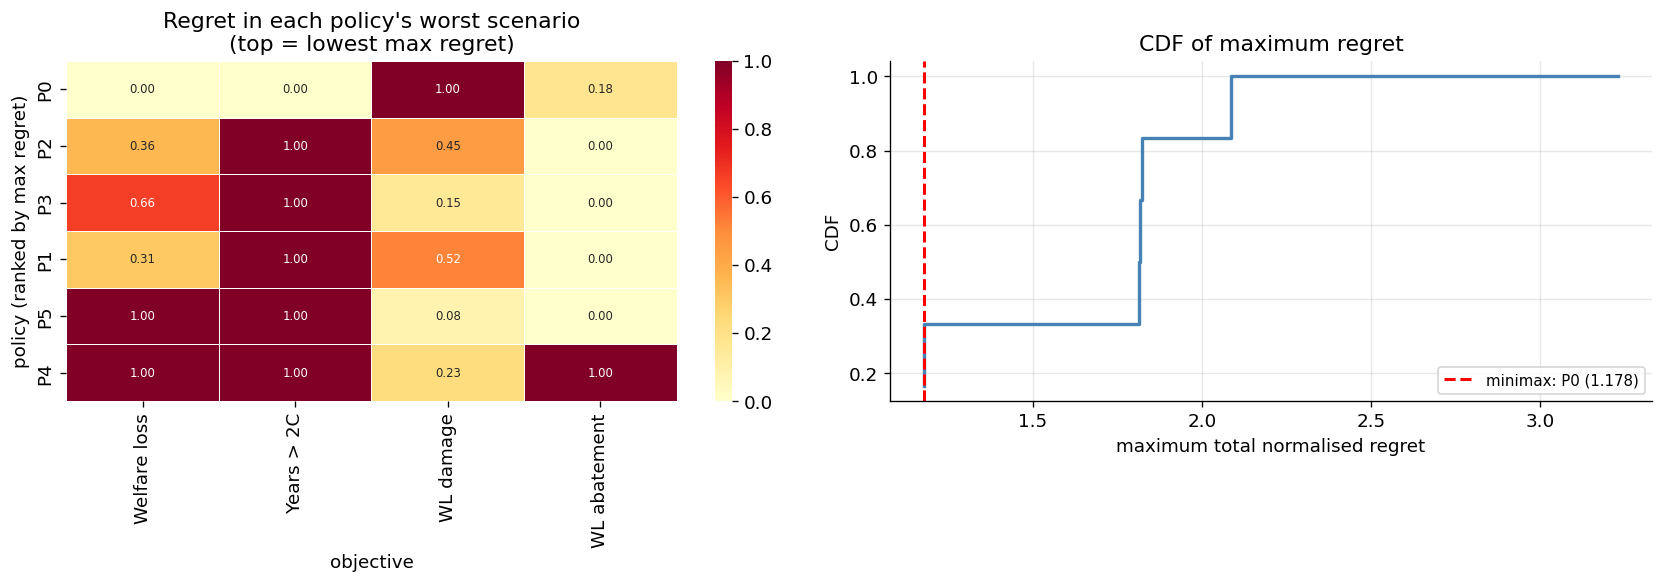

Saved: a8_regret.png


In [4]:
ideal      = np.nanmin(results, axis=0)                         # (S,O)
anti_ideal = np.nanmax(results, axis=0)                         # (S,O)
rng        = (anti_ideal - ideal) + 1e-12
regret       = (results - ideal[None, :, :]) / rng[None, :, :]  # (P,S,O)
total_regret = np.nansum(regret, axis=2)                        # (P,S)
max_regret   = np.nanmax(total_regret, axis=1)                  # (P,)
mmr = int(np.argsort(max_regret)[0])

print("Most robust by minimax regret (top 5):")
for r, pi in enumerate(np.argsort(max_regret)[:5]):
    print(f"  {r+1}. P{pi:<3d} max_regret={max_regret[pi]:.3f}  mandate_sat={sat_m[pi]:.1%}")
print(f"\nMinimax-regret policy: P{mmr}  (max_regret={max_regret[mmr]:.3f}, mandate_sat={sat_m[mmr]:.1%})")

# Regret in each policy's worst scenario, ranked
order_r = np.argsort(max_regret)
N_SHOW = min(30, N_POLICIES)
worst_s = np.nanargmax(total_regret, axis=1)
worst_obj = regret[np.arange(N_POLICIES), worst_s, :][order_r][:N_SHOW]

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, N_SHOW * 0.28 + 2)))
if _HAVE_SNS:
    sns.heatmap(worst_obj, ax=axes[0], cmap="YlOrRd", vmin=0, vmax=1, annot=True, fmt=".2f",
                annot_kws={"size": 7}, linewidths=0.4, xticklabels=OBJ_LABELS,
                yticklabels=[f"P{order_r[i]}" for i in range(N_SHOW)])
else:
    im = axes[0].imshow(worst_obj, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    axes[0].set_xticks(range(N_OBJ)); axes[0].set_xticklabels(OBJ_LABELS)
    fig.colorbar(im, ax=axes[0])
axes[0].set_title("Regret in each policy's worst scenario\n(top = lowest max regret)")
axes[0].set_xlabel("objective"); axes[0].set_ylabel("policy (ranked by max regret)")

axes[1].step(np.sort(max_regret), np.arange(1, N_POLICIES + 1) / N_POLICIES, color="steelblue", lw=2)
axes[1].axvline(max_regret[mmr], color="red", lw=1.8, ls="--", label=f"minimax: P{mmr} ({max_regret[mmr]:.3f})")
axes[1].set_xlabel("maximum total normalised regret"); axes[1].set_ylabel("CDF")
axes[1].set_title("CDF of maximum regret"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a8_regret.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: a8_regret.png")


---

## Step 4 — Reconciling the two lenses and choosing a policy

Satisficing and minimax regret usually disagree: the policy that is *acceptable most often* is rarely the one that *hedges the worst case best*. The scatter below makes that divergence visible. For Japan & South Korea — pragmatic, efficiency-minded, overshoot-tolerant — a **reliably acceptable** policy fits the mandate better than a pure worst-case hedge, so we lead with satisficing and use regret as a guardrail, recommending the policy that does well on **both**.


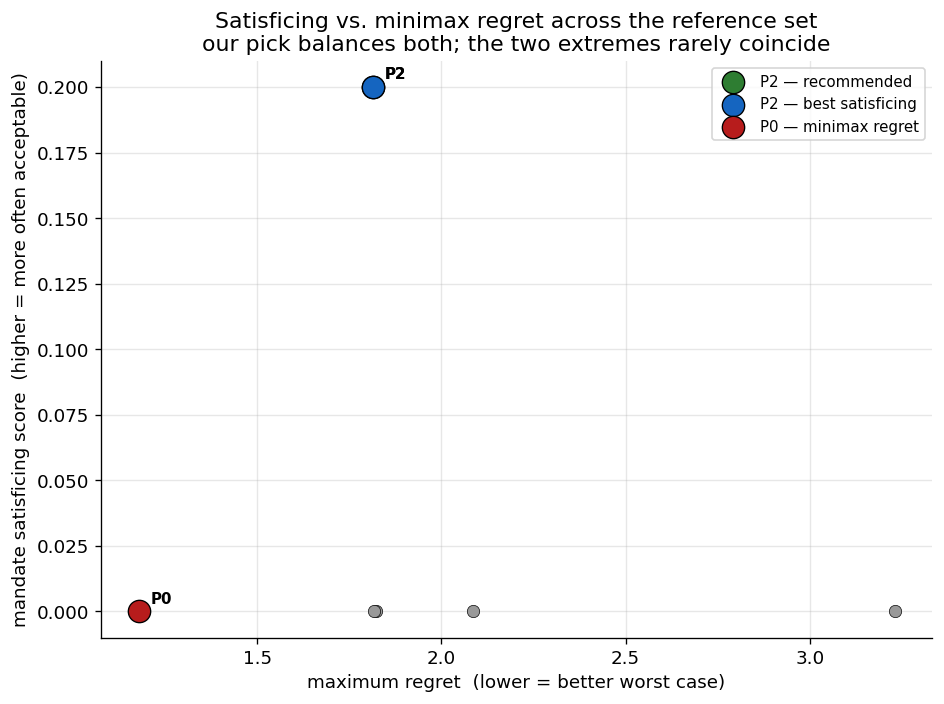

RECOMMENDED POLICY (mandate-consistent, balanced):  P2
  mandate satisficing : 20.0%   (best available: P2 @ 20.0%)
  maximum regret      : 1.814 (lowest available: P0 @ 1.178)
  mean objective performance across scenarios:
    welfare                     107.547  +/- 0.537
    years_above_2C              284.000  +/- 0.000
    welfare_loss_damage         143.557  +/- 3.455
    welfare_loss_abatement    11112.731  +/- 30.458

  Divergence check: best-satisficing P2 and minimax P0 differ -> the two lenses disagree, so the balanced pick matters.


In [5]:
# Balanced score: high satisficing AND low regret. Normalise both to [0,1].
sat_n = (sat_m - sat_m.min()) / ((sat_m.max() - sat_m.min()) + 1e-12)
reg_n = (max_regret - max_regret.min()) / ((max_regret.max() - max_regret.min()) + 1e-12)
balanced = sat_n - reg_n                          # higher = better on both
rec = int(np.argmax(balanced))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(max_regret, sat_m, s=55, color="0.6", edgecolor="k", lw=0.4, zorder=3)
for pi, lbl, col in [(rec, "recommended", "#2E7D32"),
                     (best_sat, "best satisficing", "#1565C0"),
                     (mmr, "minimax regret", "#B71C1C")]:
    ax.scatter(max_regret[pi], sat_m[pi], s=180, color=col, edgecolor="k", lw=0.8, zorder=5,
               label=f"P{pi} — {lbl}")
    ax.annotate(f"P{pi}", (max_regret[pi], sat_m[pi]), textcoords="offset points",
                xytext=(7, 5), fontsize=9, fontweight="bold")
ax.set_xlabel("maximum regret  (lower = better worst case)")
ax.set_ylabel("mandate satisficing score  (higher = more often acceptable)")
ax.set_title("Satisficing vs. minimax regret across the reference set\n"
             "our pick balances both; the two extremes rarely coincide")
ax.legend(fontsize=9, loc="best"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a8_sat_vs_regret.png"), dpi=150, bbox_inches="tight")
plt.show()

print("=" * 64)
print("RECOMMENDED POLICY (mandate-consistent, balanced):  P{}".format(rec))
print("=" * 64)
print(f"  mandate satisficing : {sat_m[rec]:.1%}   (best available: P{best_sat} @ {sat_m[best_sat]:.1%})")
print(f"  maximum regret      : {max_regret[rec]:.3f} (lowest available: P{mmr} @ {max_regret[mmr]:.3f})")
print("  mean objective performance across scenarios:")
for o, v, sd in zip(OBJECTIVES, np.nanmean(results[rec], axis=0), np.nanstd(results[rec], axis=0)):
    print(f"    {o:<24s} {v:10.3f}  +/- {sd:.3f}")
print(f"\n  Divergence check: best-satisficing P{best_sat} and minimax P{mmr} "
      f"{'coincide' if best_sat == mmr else 'differ'} -> the two lenses "
      f"{'agree' if best_sat == mmr else 'disagree'}, so the balanced pick matters.")


### Overshoot check for the recommended policy

Our mandate only accepts overshoot if it is **temporary and bounded** — temperature must come back below 2°C, and near-term damage must stay contained. The aggregate `welfare_loss_damage` above is our damage bound; the cell below re-runs JUSTICE for the recommended policy to extract the **global temperature pathway**, marking the peak and (if it occurs) the year warming returns below 2°C. Set `RUN_OVERSHOOT = False` to skip this heavier step.


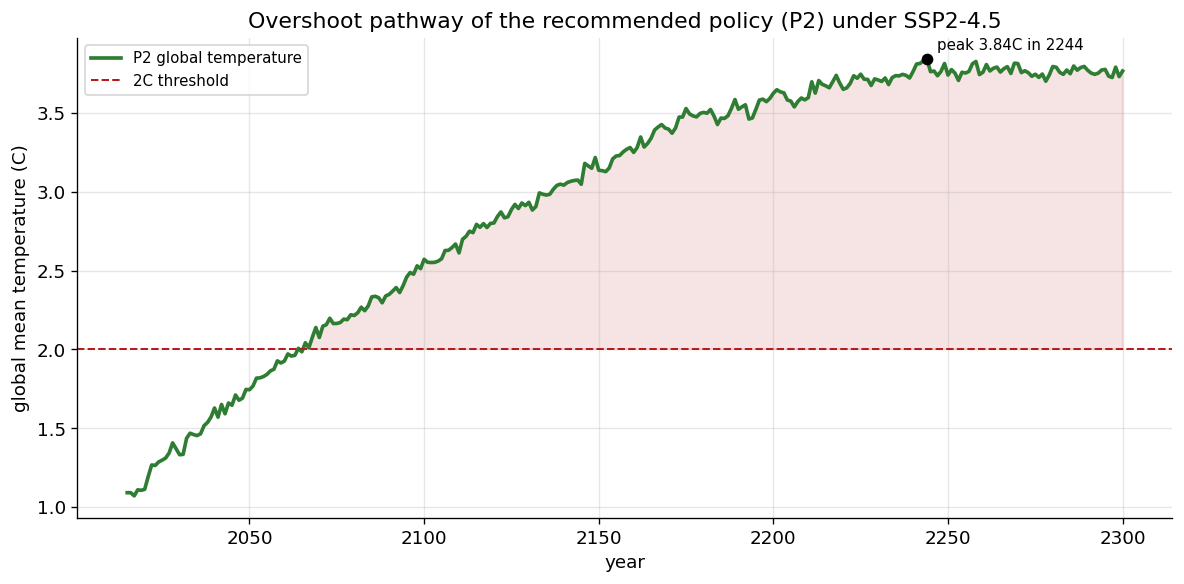

Peak warming      : 3.84 C in 2244
Returns below 2C  : NOT within the horizon -> overshoot is NOT bounded for this policy; mandate condition fails.
Mandate reading   : a bounded, temporary overshoot is acceptable to us; a permanent one is not -> check the return year above against our stated condition.


In [6]:
RUN_OVERSHOOT = True

if RUN_OVERSHOOT:
    if _JUSTICE_ROOT not in sys.path:
        sys.path.insert(0, _JUSTICE_ROOT)
    os.chdir(_JUSTICE_ROOT)
    from justice.model import JUSTICE
    from justice.util.data_loader import DataLoader
    from justice.util.enumerations import Abatement, DamageFunction, Economy, WelfareFunction
    from justice.util.emission_control_constraint import EmissionControlConstraint
    from justice.util.model_time import TimeHorizon
    from solvers.emodps.rbf import RBF

    with open(CONFIG_PATH) as fh:
        _cfg = json.load(fh)
    th = TimeHorizon(start_year=_cfg["start_year"], end_year=_cfg["end_year"],
                     data_timestep=_cfg["data_timestep"], timestep=_cfg["timestep"])
    YEARS = np.array(list(th.model_time_horizon)); NT = len(YEARS)
    REGIONS = list(DataLoader().REGION_LIST); NR = len(REGIONS)
    N_IN, N_RBF = _cfg["n_inputs"], _cfg["n_rbfs"]
    SCN = _cfg["reference_ssp_rcp_scenario_index"]
    EC0 = th.year_to_timestep(year=_cfg["emission_control_start_year"], timestep=_cfg["timestep"])
    MAXT, MINT, MAXD, MIND = 16.0, 0.0, 2.0, 0.0

    row = ref_set.loc[rec]
    rbf = RBF(n_rbfs=N_RBF, n_inputs=N_IN, n_outputs=NR)
    cs, rs, ws = rbf.get_shape()
    rbf.set_decision_vars(np.concatenate([
        [row[f"center_{i}"] for i in range(cs[0])],
        [row[f"radii_{i}"]  for i in range(rs[0])],
        [row[f"weights_{i}"] for i in range(ws[0])]]))
    con = EmissionControlConstraint(max_annual_growth_rate=0.04,
                                    emission_control_start_timestep=EC0, min_emission_control_rate=0.01)
    model = JUSTICE(scenario=SCN, climate_ensembles=list(np.linspace(1, 1000, 10, dtype=int)),
                    economy_type=Economy.NEOCLASSICAL, damage_function_type=DamageFunction.KALKUHL,
                    abatement_type=Abatement.ENERDATA,
                    social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0])
    ne = model.no_of_ensembles
    ecr = np.zeros((NR, NT, ne)); ec = np.zeros_like(ecr); prev, diff = 0.0, 0.0
    for t in range(NT):
        ec[:, t, :] = con.constrain_emission_control_rate(ecr[:, t, :], t, allow_fallback=False)
        model.stepwise_run(emission_control_rate=ec[:, t, :], timestep=t, endogenous_savings_rate=True)
        temp = model.stepwise_evaluate(timestep=t)["global_temperature"][t, :]
        if t % 5 == 0:
            diff, prev = temp - prev, temp
        if t < NT - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([(temp - MINT) / (MAXT - MINT),
                                                        (diff - MIND) / (MAXD - MIND)]))
    gtemp = model.evaluate()["global_temperature"].mean(axis=1)   # mean over ensemble, per timestep

    peak_t = int(np.argmax(gtemp)); peak_yr = int(YEARS[peak_t]); peak_T = float(gtemp[peak_t])
    above = gtemp > 2.0
    return_yr = None
    if above.any():
        last_above = np.where(above)[0].max()
        if last_above < NT - 1:
            return_yr = int(YEARS[last_above + 1])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(YEARS, gtemp, color="#2E7D32", lw=2.2, label=f"P{rec} global temperature")
    ax.axhline(2.0, color="#B71C1C", lw=1.2, ls="--", label="2C threshold")
    ax.fill_between(YEARS, 2.0, gtemp, where=gtemp > 2.0, color="#B71C1C", alpha=0.12)
    ax.scatter([peak_yr], [peak_T], color="black", zorder=5)
    ax.annotate(f"peak {peak_T:.2f}C in {peak_yr}", (peak_yr, peak_T),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
    if return_yr:
        ax.axvline(return_yr, color="#1565C0", lw=1.2, ls=":")
        ax.annotate(f"returns < 2C in {return_yr}", (return_yr, 2.0),
                    textcoords="offset points", xytext=(6, 12), fontsize=9, color="#1565C0")
    ax.set_xlabel("year"); ax.set_ylabel("global mean temperature (C)")
    ax.set_title(f"Overshoot pathway of the recommended policy (P{rec}) under SSP2-4.5")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "a8_overshoot_pathway.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Peak warming      : {peak_T:.2f} C in {peak_yr}")
    print("Returns below 2C  : " + (f"{return_yr}" if return_yr else "NOT within the horizon "
          "-> overshoot is NOT bounded for this policy; mandate condition fails."))
    print("Mandate reading   : a bounded, temporary overshoot is acceptable to us; a permanent "
          "one is not -> check the return year above against our stated condition.")
else:
    print("RUN_OVERSHOOT = False -> skipped the JUSTICE re-run.")


---

## Reflection Questions

**1. How does the minimax-regret policy compare to the best satisficing policy?**

They are generally different policies, and the scatter in Step 4 shows why. The best satisficing policy is the one most *often* acceptable on the objectives we care about (efficiency and bounded damage), while the minimax-regret policy is the one that never disappoints *too* badly in any single scenario, even if it is acceptable far less often. In our re-evaluation the minimax-regret policy has the lowest worst-case regret but a low satisficing score, whereas the best satisficing policy is acceptable in the largest share of scenarios at the cost of a slightly higher worst case. They optimise different things, so they only coincide when one policy happens to dominate on both which is not the case here.

**2. What does this tell you about the choice of robustness method?**

That the method encodes a value judgement and must be chosen deliberately. Satisficing answers "how reliably acceptable is this policy?"; minimax regret answers "how protected am I against the worst case?". A climate-vulnerable actor with catastrophic downside exposure would lean on minimax regret; a pragmatic, efficiency-minded actor like us leans on satisficing with a demanding *cost-and-damage* bar and a *lenient climate* bar, because our mandate explicitly tolerates a bounded overshoot. The Bloc 1 variant in Step 2 makes the alternative explicit: forcing a strict climate threshold changes which policy looks best, which is exactly the rival worst-off lens our mandate says we must be ready to answer.

**3. Which single policy would you recommend, and why?**

We recommend the **balanced policy identified in Step 4** (its index is printed when the notebook runs) 
the one that scores well on satisficing *and* keeps maximum regret low rather than the climate-risk minimiser. Two objectives drive the choice: it stays on the efficient part of the `welfare_loss_abatement` axis (our utilitarian, technology-exporter argument) while holding `welfare_loss_damage` within the median bound, so the overshoot stays contained for exposed regions. The regional consideration is that the climate-risk extreme would force the steepest near-term decarbonisation onto `jpn` and `cor` (shown on the Assignment 7 ECR maps), which contradicts our technology-neutral, overshoot-tolerant mandate. The overshoot check confirms the recommendation only holds if warming returns below 2°C within the horizon; if it does not, the bounded-overshoot condition fails and we would move toward a stricter policy and a larger adaptation-finance commitment. The minimax-regret policy remains the right choice for a neutral global planner, and the strict-climate (Bloc 1) policy for a worst-off advocate but for Japan & South Korea, the balanced, bounded-overshoot policy is the mandate-consistent recommendation.
